<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/Combined_RSF_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install -q scikit-survival

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 21.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score,
)
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.util import Surv

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)

BASE_DIR = Path(
    "/content/drive/MyDrive/Uniklinikum Würzburg/AML/"
    "Output Files 2/combined_survival_model_ready_wout_protocol/"
)

TRAIN_PATH = BASE_DIR / "combined_train_survival_model_ready.csv"
VALIDATION_PATH = BASE_DIR / "combined_validation_survival_model_ready.csv"
TEST_PATH = BASE_DIR / "combined_test_survival_model_ready.csv"

OUTPUT_DIR = BASE_DIR / "rsf_results" / "all_combined_features"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Training:", TRAIN_PATH)
print("Validation:", VALIDATION_PATH)
print("Test:", TEST_PATH)
print("Output:", OUTPUT_DIR)

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

DURATION_COL = "OS_DAYS"
EVENT_COL = "OS_EVENT"

PATIENT_ID_COL = "PATIENT_ID"
SAMPLE_ID_COL = "SAMPLE_ID"

EXCLUDED_COLUMNS = [
    PATIENT_ID_COL,
    SAMPLE_ID_COL,
    DURATION_COL,
    EVENT_COL,
]

OPTIONAL_METADATA_COLUMNS = [
    # "DATASET_SPLIT",
    # "SOURCE",
    # "SAMPLE_DATE",
    # "DIAGNOSIS_DATE",
    # "FOLLOW_UP_STATUS",
]

EXCLUDED_COLUMNS = list(
    dict.fromkeys(
        EXCLUDED_COLUMNS + OPTIONAL_METADATA_COLUMNS
    )
)

candidate_features = [
    column
    for column in train_df.columns
    if column not in EXCLUDED_COLUMNS
]

print("Candidate feature count:", len(candidate_features))
print(candidate_features)

Training: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/combined_train_survival_model_ready.csv
Validation: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/combined_validation_survival_model_ready.csv
Test: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/combined_test_survival_model_ready.csv
Output: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/rsf_results/all_combined_features
Training shape: (620, 68)
Validation shape: (177, 68)
Test shape: (89, 68)


,PATIENT_ID,AGE,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,PERIPHERAL_BLASTS_PERCENTAGE,WBC_LOG1P,SEX_Female,SEX_Male,RACE_American Indian or Alaska Native,RACE_Asian,RACE_Black or African American,RACE_Native Hawaiian or other Pacific Islander,RACE_Other,RACE_White,ETHNICITY_Hispanic or Latino,ETHNICITY_Not Hispanic or Latino,CNS_DISEASE_No,CNS_DISEASE_Yes,CHLOROMA_No,CHLOROMA_Yes,FAB_M0,FAB_M1,FAB_M2,FAB_M4,FAB_M5,FAB_M6,FAB_M7,FAB_NOS,PRIMARY_CYTOGENETIC_CODE_MLL,PRIMARY_CYTOGENETIC_CODE_Normal,PRIMARY_CYTOGENETIC_CODE_Other,PRIMARY_CYTOGENETIC_CODE_inv(16),PRIMARY_CYTOGENETIC_CODE_t(8;21),RISK_GROUP_CLEAN_High,RISK_GROUP_CLEAN_Low,RISK_GROUP_CLEAN_Missing,RISK_GROUP_CLEAN_Standard,CYTOGENETIC_COMPLEXITY_GROUP_0,CYTOGENETIC_COMPLEXITY_GROUP_1,CYTOGENETIC_COMPLEXITY_GROUP_2,CYTOGENETIC_COMPLEXITY_GROUP_3,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,OS_DAYS,OS_EVENT,SAMPLE_ID,T_6_9,T_8_21,T_3_5_Q25_Q34,T_6_11_Q27_Q23,T_9_11_P22_Q23,T_10_11_P11_2_Q23,T_11_19_Q23_P13_1,INV_16,DEL_5Q,DEL_7Q,DEL_9Q,MONOSOMY_5,MONOSOMY_7,TRISOMY_8,TRISOMY_21,MLL,MINUS_Y,MINUS_X,FLT3_ITD_POSITIVE,FLT3_PM,NPM_MUTATION,CEBPA_MUTATION,WT1_MUTATION,FLT3_ITD_ALLELIC_RATIO_LOG1P
0,TARGET-20-PARNIL,0.805504,0.201872,-0.882435,1.420665,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,TARGET-20-PARNIL-09,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.323440
1,TARGET-20-PAPZYS,-0.477096,1.024895,-1.447140,-1.911679,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2566.0,0.0,TARGET-20-PAPZYS-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-0.323440
2,TARGET-20-PASKUA,0.164204,0.168951,0.623447,0.661814,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,721.0,1.0,TARGET-20-PASKUA-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1.322296
3,TARGET-20-PARMME,0.164204,1.024895,0.466584,-0.435777,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2363.0,0.0,TARGET-20-PARMME-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1.410749
4,TARGET-20-PARTYV,-0.797747,0.613384,0.560702,0.818136,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,406.0,0.0,TARGET-20-PARTYV-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,2.110204


Candidate feature count: 64
['AGE', 'BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE', 'PERIPHERAL_BLASTS_PERCENTAGE', 'WBC_LOG1P', 'SEX_Female', 'SEX_Male', 'RACE_American Indian or Alaska Native', 'RACE_Asian', 'RACE_Black or African American', 'RACE_Native Hawaiian or other Pacific Islander', 'RACE_Other', 'RACE_White', 'ETHNICITY_Hispanic or Latino', 'ETHNICITY_Not Hispanic or Latino', 'CNS_DISEASE_No', 'CNS_DISEASE_Yes', 'CHLOROMA_No', 'CHLOROMA_Yes', 'FAB_M0', 'FAB_M1', 'FAB_M2', 'FAB_M4', 'FAB_M5', 'FAB_M6', 'FAB_M7', 'FAB_NOS', 'PRIMARY_CYTOGENETIC_CODE_MLL', 'PRIMARY_CYTOGENETIC_CODE_Normal', 'PRIMARY_CYTOGENETIC_CODE_Other', 'PRIMARY_CYTOGENETIC_CODE_inv(16)', 'PRIMARY_CYTOGENETIC_CODE_t(8;21)', 'RISK_GROUP_CLEAN_High', 'RISK_GROUP_CLEAN_Low', 'RISK_GROUP_CLEAN_Missing', 'RISK_GROUP_CLEAN_Standard', 'CYTOGENETIC_COMPLEXITY_GROUP_0', 'CYTOGENETIC_COMPLEXITY_GROUP_1', 'CYTOGENETIC_COMPLEXITY_GROUP_2', 'CYTOGENETIC_COMPLEXITY_GROUP_3', 'CYTOGENETIC_COMPLEXITY_GROUP_4_plus', 'T_6_9', 'T_8_

In [ ]:
non_numeric_features = [
    column
    for column in candidate_features
    if not pd.api.types.is_numeric_dtype(train_df[column])
]

print("Nonnumeric candidate features:")
print(non_numeric_features)

Nonnumeric candidate features:
[]


In [ ]:
if non_numeric_features:
    raise ValueError(
        "These candidate features are not numeric:\n"
        + "\n".join(non_numeric_features)
        + "\n\nOne-hot encode them or add them to "
          "OPTIONAL_METADATA_COLUMNS."
    )

In [ ]:
REQUESTED_FEATURES = candidate_features.copy()

print("Number of requested predictors:", len(REQUESTED_FEATURES))

Number of requested predictors: 64


In [ ]:
for number, feature in enumerate(REQUESTED_FEATURES, start=1):
    print(number, feature)

1 AGE
2 BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE
3 PERIPHERAL_BLASTS_PERCENTAGE
4 WBC_LOG1P
5 SEX_Female
6 SEX_Male
7 RACE_American Indian or Alaska Native
8 RACE_Asian
9 RACE_Black or African American
10 RACE_Native Hawaiian or other Pacific Islander
11 RACE_Other
12 RACE_White
13 ETHNICITY_Hispanic or Latino
14 ETHNICITY_Not Hispanic or Latino
15 CNS_DISEASE_No
16 CNS_DISEASE_Yes
17 CHLOROMA_No
18 CHLOROMA_Yes
19 FAB_M0
20 FAB_M1
21 FAB_M2
22 FAB_M4
23 FAB_M5
24 FAB_M6
25 FAB_M7
26 FAB_NOS
27 PRIMARY_CYTOGENETIC_CODE_MLL
28 PRIMARY_CYTOGENETIC_CODE_Normal
29 PRIMARY_CYTOGENETIC_CODE_Other
30 PRIMARY_CYTOGENETIC_CODE_inv(16)
31 PRIMARY_CYTOGENETIC_CODE_t(8;21)
32 RISK_GROUP_CLEAN_High
33 RISK_GROUP_CLEAN_Low
34 RISK_GROUP_CLEAN_Missing
35 RISK_GROUP_CLEAN_Standard
36 CYTOGENETIC_COMPLEXITY_GROUP_0
37 CYTOGENETIC_COMPLEXITY_GROUP_1
38 CYTOGENETIC_COMPLEXITY_GROUP_2
39 CYTOGENETIC_COMPLEXITY_GROUP_3
40 CYTOGENETIC_COMPLEXITY_GROUP_4_plus
41 T_6_9
42 T_8_21
43 T_3_5_Q25_Q34
44 T_6_11_Q27_Q2

In [ ]:
def validate_dataset(
    df: pd.DataFrame,
    dataset_name: str,
    features: list[str],
) -> None:
    required_columns = features + [
        DURATION_COL,
        EVENT_COL,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing columns:\n"
            + "\n".join(missing_columns)
        )

    if df[DURATION_COL].isna().any():
        raise ValueError(
            f"{dataset_name}: {DURATION_COL} contains missing values."
        )

    if df[EVENT_COL].isna().any():
        raise ValueError(
            f"{dataset_name}: {EVENT_COL} contains missing values."
        )

    if (df[DURATION_COL] <= 0).any():
        raise ValueError(
            f"{dataset_name}: {DURATION_COL} must be greater than zero."
        )

    if not df[EVENT_COL].isin([0, 1]).all():
        invalid_values = sorted(
            df.loc[
                ~df[EVENT_COL].isin([0, 1]),
                EVENT_COL,
            ].unique()
        )

        raise ValueError(
            f"{dataset_name}: {EVENT_COL} must contain 0 or 1. "
            f"Invalid values: {invalid_values}"
        )

    feature_missingness = df[features].isna().sum()

    if feature_missingness.sum() > 0:
        print(f"\nMissing features in {dataset_name}:")

        display(
            feature_missingness[
                feature_missingness > 0
            ].sort_values(ascending=False)
        )

        raise ValueError(
            f"{dataset_name} contains missing predictor values."
        )

    print(
        f"{dataset_name}: "
        f"n={len(df)}, "
        f"events={int(df[EVENT_COL].sum())}, "
        f"censored={int((df[EVENT_COL] == 0).sum())}, "
        f"event rate={df[EVENT_COL].mean():.3f}"
    )

In [ ]:
validate_dataset(
    train_df,
    "Training set",
    REQUESTED_FEATURES,
)

validate_dataset(
    validation_df,
    "Validation set",
    REQUESTED_FEATURES,
)

validate_dataset(
    test_df,
    "Test set",
    REQUESTED_FEATURES,
)

Training set: n=620, events=223, censored=397, event rate=0.360
Validation set: n=177, events=63, censored=114, event rate=0.356
Test set: n=89, events=32, censored=57, event rate=0.360


In [ ]:
def check_patient_overlap(
    train_data: pd.DataFrame,
    validation_data: pd.DataFrame,
    test_data: pd.DataFrame,
) -> None:
    if PATIENT_ID_COL not in train_data.columns:
        print(
            f"{PATIENT_ID_COL} not found. "
            "Patient-overlap check skipped."
        )
        return

    train_ids = set(
        train_data[PATIENT_ID_COL]
        .dropna()
        .astype(str)
    )

    validation_ids = set(
        validation_data[PATIENT_ID_COL]
        .dropna()
        .astype(str)
    )

    test_ids = set(
        test_data[PATIENT_ID_COL]
        .dropna()
        .astype(str)
    )

    overlaps = {
        "Train–Validation": train_ids & validation_ids,
        "Train–Test": train_ids & test_ids,
        "Validation–Test": validation_ids & test_ids,
    }

    overlap_detected = False

    for comparison, overlap in overlaps.items():
        print(f"{comparison} overlap: {len(overlap)}")

        if overlap:
            overlap_detected = True
            print("Example IDs:", list(overlap)[:10])

    if overlap_detected:
        raise ValueError(
            "Patients overlap across splits. "
            "This creates data leakage."
        )

    print("No patient overlap detected.")

In [ ]:
check_patient_overlap(
    train_df,
    validation_df,
    test_df,
)

Train–Validation overlap: 0
Train–Test overlap: 0
Validation–Test overlap: 0
No patient overlap detected.


In [ ]:
zero_variance_features = [
    feature
    for feature in REQUESTED_FEATURES
    if train_df[feature].nunique(dropna=True) <= 1
]

MODEL_FEATURES = [
    feature
    for feature in REQUESTED_FEATURES
    if feature not in zero_variance_features
]

print("Zero-variance features removed:")
print(zero_variance_features)

print("\nPredictors retained:", len(MODEL_FEATURES))

if not MODEL_FEATURES:
    raise ValueError(
        "No predictors remain after zero-variance filtering."
    )

Zero-variance features removed:
[]

Predictors retained: 64


In [ ]:
pd.DataFrame({
    "zero_variance_feature": zero_variance_features
}).to_csv(
    OUTPUT_DIR / "zero_variance_features_removed.csv",
    index=False,
)

In [ ]:
def create_feature_summary(
    df: pd.DataFrame,
    features: list[str],
) -> pd.DataFrame:
    rows = []

    for feature in features:
        values = pd.to_numeric(
            df[feature],
            errors="coerce",
        )

        unique_values = values.dropna().unique()
        is_binary = set(unique_values).issubset({0, 1})

        rows.append({
            "feature": feature,
            "n_unique": int(values.nunique()),
            "minimum": float(values.min()),
            "maximum": float(values.max()),
            "mean": float(values.mean()),
            "standard_deviation": float(values.std()),
            "is_binary": bool(is_binary),
            "n_positive": (
                int((values == 1).sum())
                if is_binary
                else np.nan
            ),
            "prevalence": (
                float(values.mean())
                if is_binary
                else np.nan
            ),
        })

    return pd.DataFrame(rows)

In [ ]:
feature_summary_df = create_feature_summary(
    train_df,
    MODEL_FEATURES,
)

display(feature_summary_df)

feature_summary_df.to_csv(
    OUTPUT_DIR / "combined_feature_summary.csv",
    index=False,
)

,feature,n_unique,minimum,maximum,mean,standard_deviation,is_binary,n_positive,prevalence
0,AGE,26,-1.439047,3.210380,-1.074409e-16,1.000807,False,NaN,NaN
1,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,187,-2.678707,1.436406,-8.022257e-17,1.000807,False,NaN,NaN
2,PERIPHERAL_BLASTS_PERCENTAGE,128,-1.447140,1.658740,6.912034e-17,1.000807,False,NaN,NaN
3,WBC_LOG1P,452,-2.533576,2.246302,-1.661753e-16,1.000807,False,NaN,NaN
4,SEX_Female,2,0.000000,1.000000,5.000000e-01,0.500404,True,310.0,0.500000
5,SEX_Male,2,0.000000,1.000000,5.000000e-01,0.500404,True,310.0,0.500000
6,RACE_American Indian or Alaska Native,2,0.000000,1.000000,4.838710e-03,0.069448,True,3.0,0.004839
7,RACE_Asian,2,0.000000,1.000000,5.000000e-02,0.218121,True,31.0,0.050000
8,RACE_Black or African American,2,0.000000,1.000000,1.096774e-01,0.312740,True,68.0,0.109677
9,RACE_Native Hawaiian or other Pacific Islander,2,0.000000,1.000000,3.225806e-03,0.056750,True,2.0,0.003226


In [ ]:
def prepare_predictors(
    df: pd.DataFrame,
    features: list[str],
) -> pd.DataFrame:
    X = df[features].copy()

    for feature in features:
        X[feature] = pd.to_numeric(
            X[feature],
            errors="raise",
        ).astype(float)

    if X.isna().any().any():
        problematic = (
            X.columns[
                X.isna().any()
            ].tolist()
        )

        raise ValueError(
            f"Missing predictor values remain in: {problematic}"
        )

    return X

In [ ]:
X_train = prepare_predictors(
    train_df,
    MODEL_FEATURES,
)

X_validation = prepare_predictors(
    validation_df,
    MODEL_FEATURES,
)

X_test = prepare_predictors(
    test_df,
    MODEL_FEATURES,
)

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

X_train: (620, 64)
X_validation: (177, 64)
X_test: (89, 64)


In [ ]:
def prepare_survival_outcome(
    df: pd.DataFrame,
) -> np.ndarray:
    return Surv.from_arrays(
        event=df[EVENT_COL].astype(bool).to_numpy(),
        time=df[DURATION_COL].astype(float).to_numpy(),
    )

y_train = prepare_survival_outcome(train_df)
y_validation = prepare_survival_outcome(validation_df)
y_test = prepare_survival_outcome(test_df)



In [ ]:
RSF_CONFIGURATIONS = [
    {
        "configuration": "500 trees, depth 5",
        "n_estimators": 500,
        "max_depth": 5,
    },
    {
        "configuration": "1000 trees, depth 5",
        "n_estimators": 1000,
        "max_depth": 5,
    },
    {
        "configuration": "500 trees, depth 10",
        "n_estimators": 500,
        "max_depth": 10,
    },
    {
        "configuration": "1000 trees, depth 10",
        "n_estimators": 1000,
        "max_depth": 10,
    },
]

display(pd.DataFrame(RSF_CONFIGURATIONS))

,configuration,n_estimators,max_depth
0,"500 trees, depth 5",500,5
1,"1000 trees, depth 5",1000,5
2,"500 trees, depth 10",500,10
3,"1000 trees, depth 10",1000,10


In [ ]:
FIXED_RSF_PARAMETERS = {
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_features": "sqrt",
    "bootstrap": True,
    "oob_score": True,
    "n_jobs": -1,
    "random_state": 42,
}

In [ ]:
def calculate_c_index(
    model: RandomSurvivalForest,
    X: pd.DataFrame,
    y: np.ndarray,
) -> tuple[float, np.ndarray]:
    risk_scores = model.predict(X)

    c_index = concordance_index_censored(
        y["event"],
        y["time"],
        risk_scores,
    )[0]

    return float(c_index), risk_scores

In [ ]:
REQUESTED_AUC_TIMES = np.array(
    [
        365,   # 1 year
        730,   # 2 years
        1095,  # 3 years
        1825,  # 5 years
    ],
    dtype=float,
)

In [ ]:
def get_valid_auc_times(
    requested_times: np.ndarray,
    training_survival: np.ndarray,
    evaluation_survival: np.ndarray,
) -> np.ndarray:
    lower_bound = max(
        float(training_survival["time"].min()),
        float(evaluation_survival["time"].min()),
    )

    upper_bound = min(
        float(training_survival["time"].max()),
        float(evaluation_survival["time"].max()),
    )

    valid_times = requested_times[
        (requested_times > lower_bound)
        & (requested_times < upper_bound)
    ]

    if len(valid_times) == 0:
        raise ValueError(
            "None of the requested AUC times are supported."
        )

    excluded_times = requested_times[
        ~np.isin(requested_times, valid_times)
    ]

    if len(excluded_times) > 0:
        print(
            "Excluded unsupported AUC times:",
            excluded_times.tolist(),
        )

    return valid_times

In [ ]:
def calculate_time_dependent_auc(
    training_survival: np.ndarray,
    evaluation_survival: np.ndarray,
    risk_scores: np.ndarray,
    requested_times: np.ndarray,
) -> tuple[pd.DataFrame, float]:
    valid_times = get_valid_auc_times(
        requested_times,
        training_survival,
        evaluation_survival,
    )

    auc_values, mean_auc = cumulative_dynamic_auc(
        training_survival,
        evaluation_survival,
        risk_scores,
        valid_times,
    )

    auc_df = pd.DataFrame({
        "time_days": valid_times,
        "time_years": valid_times / 365.25,
        "auc": auc_values,
    })

    return auc_df, float(mean_auc)

In [ ]:
def create_brier_time_grid(
    training_survival: np.ndarray,
    evaluation_survival: np.ndarray,
    n_times: int = 100,
) -> np.ndarray:
    lower_bound = max(
        float(training_survival["time"].min()),
        float(evaluation_survival["time"].min()),
    )

    upper_bound = min(
        float(training_survival["time"].max()),
        float(evaluation_survival["time"].max()),
    )

    evaluation_times = evaluation_survival["time"]

    start = max(
        lower_bound + 1.0,
        float(np.quantile(evaluation_times, 0.10)),
    )

    stop = min(
        upper_bound - 1.0,
        float(np.quantile(evaluation_times, 0.90)),
    )

    if start >= stop:
        raise ValueError(
            "A valid IBS time range could not be created."
        )

    return np.linspace(
        start,
        stop,
        n_times,
    )

In [ ]:
def predict_survival_probability_matrix(
    model: RandomSurvivalForest,
    X: pd.DataFrame,
    times: np.ndarray,
) -> np.ndarray:
    survival_functions = model.predict_survival_function(X)

    return np.row_stack([
        survival_function(times)
        for survival_function in survival_functions
    ])

In [ ]:
def calculate_integrated_brier_score(
    model: RandomSurvivalForest,
    X: pd.DataFrame,
    training_survival: np.ndarray,
    evaluation_survival: np.ndarray,
) -> tuple[float, np.ndarray]:
    brier_times = create_brier_time_grid(
        training_survival,
        evaluation_survival,
    )

    survival_probabilities = (
        predict_survival_probability_matrix(
            model,
            X,
            brier_times,
        )
    )

    ibs = integrated_brier_score(
        training_survival,
        evaluation_survival,
        survival_probabilities,
        brier_times,
    )

    return float(ibs), brier_times

In [ ]:
configuration_results = []
fitted_models = {}
auc_results = {}

for config in RSF_CONFIGURATIONS:
    configuration_name = config["configuration"]

    print("\n" + "=" * 75)
    print("Training:", configuration_name)
    print("Predictors:", len(MODEL_FEATURES))
    print("Trees:", config["n_estimators"])
    print("Maximum depth:", config["max_depth"])
    print("=" * 75)

    try:
        model = RandomSurvivalForest(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_split=(
                FIXED_RSF_PARAMETERS["min_samples_split"]
            ),
            min_samples_leaf=(
                FIXED_RSF_PARAMETERS["min_samples_leaf"]
            ),
            max_features=(
                FIXED_RSF_PARAMETERS["max_features"]
            ),
            bootstrap=FIXED_RSF_PARAMETERS["bootstrap"],
            oob_score=FIXED_RSF_PARAMETERS["oob_score"],
            n_jobs=FIXED_RSF_PARAMETERS["n_jobs"],
            random_state=FIXED_RSF_PARAMETERS["random_state"],
        )

        model.fit(X_train, y_train)

        # C-index
        train_c_index, train_risk_scores = (
            calculate_c_index(
                model,
                X_train,
                y_train,
            )
        )

        validation_c_index, validation_risk_scores = (
            calculate_c_index(
                model,
                X_validation,
                y_validation,
            )
        )

        test_c_index, test_risk_scores = (
            calculate_c_index(
                model,
                X_test,
                y_test,
            )
        )

        # AUC
        validation_auc_df, validation_mean_auc = (
            calculate_time_dependent_auc(
                y_train,
                y_validation,
                validation_risk_scores,
                REQUESTED_AUC_TIMES,
            )
        )

        test_auc_df, test_mean_auc = (
            calculate_time_dependent_auc(
                y_train,
                y_test,
                test_risk_scores,
                REQUESTED_AUC_TIMES,
            )
        )

        # IBS
        validation_ibs, validation_brier_times = (
            calculate_integrated_brier_score(
                model,
                X_validation,
                y_train,
                y_validation,
            )
        )

        test_ibs, test_brier_times = (
            calculate_integrated_brier_score(
                model,
                X_test,
                y_train,
                y_test,
            )
        )

        print(f"Train C-index: {train_c_index:.4f}")
        print(f"OOB C-index: {model.oob_score_:.4f}")

        print(f"Validation C-index: {validation_c_index:.4f}")
        print(f"Validation IBS: {validation_ibs:.4f}")
        print(f"Validation mean AUC: {validation_mean_auc:.4f}")

        print(f"Test C-index: {test_c_index:.4f}")
        print(f"Test IBS: {test_ibs:.4f}")
        print(f"Test mean AUC: {test_mean_auc:.4f}")

        configuration_results.append({
            "feature_set": "All Combined Features",
            "configuration": configuration_name,
            "n_estimators": config["n_estimators"],
            "max_depth": config["max_depth"],
            "min_samples_split":
                FIXED_RSF_PARAMETERS["min_samples_split"],
            "min_samples_leaf":
                FIXED_RSF_PARAMETERS["min_samples_leaf"],
            "max_features":
                FIXED_RSF_PARAMETERS["max_features"],
            "n_requested_features": len(REQUESTED_FEATURES),
            "n_used_features": len(MODEL_FEATURES),
            "train_c_index": train_c_index,
            "oob_c_index": float(model.oob_score_),
            "validation_c_index": validation_c_index,
            "test_c_index": test_c_index,
            "train_validation_gap":
                train_c_index - validation_c_index,
            "validation_ibs": validation_ibs,
            "test_ibs": test_ibs,
            "validation_mean_auc": validation_mean_auc,
            "test_mean_auc": test_mean_auc,
            "completed": True,
            "error": None,
        })

        fitted_models[configuration_name] = model

        auc_results[configuration_name] = {
            "validation": validation_auc_df,
            "test": test_auc_df,
        }

    except Exception as error:
        print(
            f"Configuration '{configuration_name}' failed: {error}"
        )

        configuration_results.append({
            "feature_set": "All Combined Features",
            "configuration": configuration_name,
            "n_estimators": config["n_estimators"],
            "max_depth": config["max_depth"],
            "min_samples_split":
                FIXED_RSF_PARAMETERS["min_samples_split"],
            "min_samples_leaf":
                FIXED_RSF_PARAMETERS["min_samples_leaf"],
            "max_features":
                FIXED_RSF_PARAMETERS["max_features"],
            "n_requested_features": len(REQUESTED_FEATURES),
            "n_used_features": len(MODEL_FEATURES),
            "train_c_index": np.nan,
            "oob_c_index": np.nan,
            "validation_c_index": np.nan,
            "test_c_index": np.nan,
            "train_validation_gap": np.nan,
            "validation_ibs": np.nan,
            "test_ibs": np.nan,
            "validation_mean_auc": np.nan,
            "test_mean_auc": np.nan,
            "completed": False,
            "error": str(error),
        })


Training: 500 trees, depth 5
Predictors: 64
Trees: 500
Maximum depth: 5
Train C-index: 0.7751
OOB C-index: 0.6452
Validation C-index: 0.6911
Validation IBS: 0.1889
Validation mean AUC: 0.7163
Test C-index: 0.6841
Test IBS: 0.1870
Test mean AUC: 0.7298

Training: 1000 trees, depth 5
Predictors: 64
Trees: 1000
Maximum depth: 5
Train C-index: 0.7741
OOB C-index: 0.6469
Validation C-index: 0.6939
Validation IBS: 0.1883
Validation mean AUC: 0.7189
Test C-index: 0.6841
Test IBS: 0.1860
Test mean AUC: 0.7284

Training: 500 trees, depth 10
Predictors: 64
Trees: 500
Maximum depth: 10
Train C-index: 0.8331
OOB C-index: 0.6533
Validation C-index: 0.6929
Validation IBS: 0.1831
Validation mean AUC: 0.7151
Test C-index: 0.6745
Test IBS: 0.1840
Test mean AUC: 0.7168

Training: 1000 trees, depth 10
Predictors: 64
Trees: 1000
Maximum depth: 10
Train C-index: 0.8333
OOB C-index: 0.6522
Validation C-index: 0.6944
Validation IBS: 0.1824
Validation mean AUC: 0.7145
Test C-index: 0.6745
Test IBS: 0.1831
Te

In [ ]:
configuration_results_df = pd.DataFrame(
    configuration_results
)

configuration_results_df = (
    configuration_results_df
    .sort_values(
        by=[
            "validation_c_index",
            "validation_ibs",
            "validation_mean_auc",
            "train_validation_gap",
        ],
        ascending=[
            False,
            True,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(configuration_results_df)

,feature_set,configuration,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,n_requested_features,n_used_features,train_c_index,oob_c_index,validation_c_index,test_c_index,train_validation_gap,validation_ibs,test_ibs,validation_mean_auc,test_mean_auc,completed,error
0,All Combined Features,"1000 trees, depth 10",1000,10,10,5,sqrt,64,64,0.833332,0.652224,0.694391,0.674535,0.138941,0.182447,0.183097,0.714497,0.719857,True,None
1,All Combined Features,"1000 trees, depth 5",1000,5,10,5,sqrt,64,64,0.774083,0.646920,0.693940,0.684067,0.080143,0.188340,0.185959,0.718912,0.728425,True,None
2,All Combined Features,"500 trees, depth 10",500,10,10,5,sqrt,64,64,0.833148,0.653329,0.692924,0.674535,0.140224,0.183057,0.183975,0.715106,0.716813,True,None
3,All Combined Features,"500 trees, depth 5",500,5,10,5,sqrt,64,64,0.775114,0.645217,0.691118,0.684067,0.083996,0.188889,0.186955,0.716349,0.729818,True,None


In [ ]:
configuration_results_df.to_csv(
    OUTPUT_DIR / "rsf_all_combined_configuration_results.csv",
    index=False,
)

In [ ]:
successful_results_df = configuration_results_df.loc[
    configuration_results_df["completed"]
].copy()

if successful_results_df.empty:
    raise RuntimeError(
        "No RSF configuration completed successfully."
    )

best_result = successful_results_df.iloc[0]

BEST_CONFIGURATION = best_result["configuration"]
best_model = fitted_models[BEST_CONFIGURATION]

print("=" * 75)
print("SELECTED RSF MODEL")
print("=" * 75)

print("Configuration:", BEST_CONFIGURATION)
print("Trees:", int(best_result["n_estimators"]))
print("Maximum depth:", int(best_result["max_depth"]))
print("Predictors:", len(MODEL_FEATURES))

print(
    "Validation C-index:",
    round(best_result["validation_c_index"], 4),
)

print(
    "Validation IBS:",
    round(best_result["validation_ibs"], 4),
)

print(
    "Validation mean AUC:",
    round(best_result["validation_mean_auc"], 4),
)

print("=" * 75)

SELECTED RSF MODEL
Configuration: 1000 trees, depth 10
Trees: 1000
Maximum depth: 10
Predictors: 64
Validation C-index: 0.6944
Validation IBS: 0.1824
Validation mean AUC: 0.7145


In [ ]:
train_c_index, train_risk_scores = calculate_c_index(
    best_model,
    X_train,
    y_train,
)

validation_c_index, validation_risk_scores = (
    calculate_c_index(
        best_model,
        X_validation,
        y_validation,
    )
)

test_c_index, test_risk_scores = calculate_c_index(
    best_model,
    X_test,
    y_test,
)

In [ ]:
validation_auc_df, validation_mean_auc = (
    calculate_time_dependent_auc(
        y_train,
        y_validation,
        validation_risk_scores,
        REQUESTED_AUC_TIMES,
    )
)

test_auc_df, test_mean_auc = (
    calculate_time_dependent_auc(
        y_train,
        y_test,
        test_risk_scores,
        REQUESTED_AUC_TIMES,
    )
)

In [ ]:
validation_ibs, validation_brier_times = (
    calculate_integrated_brier_score(
        best_model,
        X_validation,
        y_train,
        y_validation,
    )
)

test_ibs, test_brier_times = (
    calculate_integrated_brier_score(
        best_model,
        X_test,
        y_train,
        y_test,
    )
)

In [ ]:
final_metrics_df = pd.DataFrame({
    "model": [
        "Random Survival Forest",
        "Random Survival Forest",
        "Random Survival Forest",
    ],
    "feature_set": [
        "All Combined Features",
        "All Combined Features",
        "All Combined Features",
    ],
    "configuration": [
        BEST_CONFIGURATION,
        BEST_CONFIGURATION,
        BEST_CONFIGURATION,
    ],
    "dataset": [
        "Training",
        "Validation",
        "Test",
    ],
    "n_patients": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],
    "n_events": [
        int(train_df[EVENT_COL].sum()),
        int(validation_df[EVENT_COL].sum()),
        int(test_df[EVENT_COL].sum()),
    ],
    "n_features": [
        len(MODEL_FEATURES),
        len(MODEL_FEATURES),
        len(MODEL_FEATURES),
    ],
    "c_index": [
        train_c_index,
        validation_c_index,
        test_c_index,
    ],
    "integrated_brier_score": [
        np.nan,
        validation_ibs,
        test_ibs,
    ],
    "mean_time_dependent_auc": [
        np.nan,
        validation_mean_auc,
        test_mean_auc,
    ],
    "oob_c_index_training": [
        best_model.oob_score_,
        best_model.oob_score_,
        best_model.oob_score_,
    ],
})

display(final_metrics_df)

,model,feature_set,configuration,dataset,n_patients,n_events,n_features,c_index,integrated_brier_score,mean_time_dependent_auc,oob_c_index_training
0,Random Survival Forest,All Combined Features,"1000 trees, depth 10",Training,620,223,64,0.833332,NaN,NaN,0.652224
1,Random Survival Forest,All Combined Features,"1000 trees, depth 10",Validation,177,63,64,0.694391,0.182447,0.714497,0.652224
2,Random Survival Forest,All Combined Features,"1000 trees, depth 10",Test,89,32,64,0.674535,0.183097,0.719857,0.652224


In [ ]:
final_metrics_df.to_csv(
    OUTPUT_DIR / "rsf_all_combined_final_metrics.csv",
    index=False,
)

In [ ]:
validation_auc_output = validation_auc_df.copy()
validation_auc_output["dataset"] = "Validation"

test_auc_output = test_auc_df.copy()
test_auc_output["dataset"] = "Test"

all_auc_df = pd.concat(
    [
        validation_auc_output,
        test_auc_output,
    ],
    ignore_index=True,
)

display(all_auc_df)

,time_days,time_years,auc,dataset
0,365.0,0.999316,0.701500,Validation
1,730.0,1.998631,0.724690,Validation
2,1095.0,2.997947,0.724042,Validation
3,1825.0,4.996578,0.721158,Validation
4,365.0,0.999316,0.742400,Test
5,730.0,1.998631,0.708273,Test
6,1095.0,2.997947,0.686776,Test
7,1825.0,4.996578,0.717693,Test


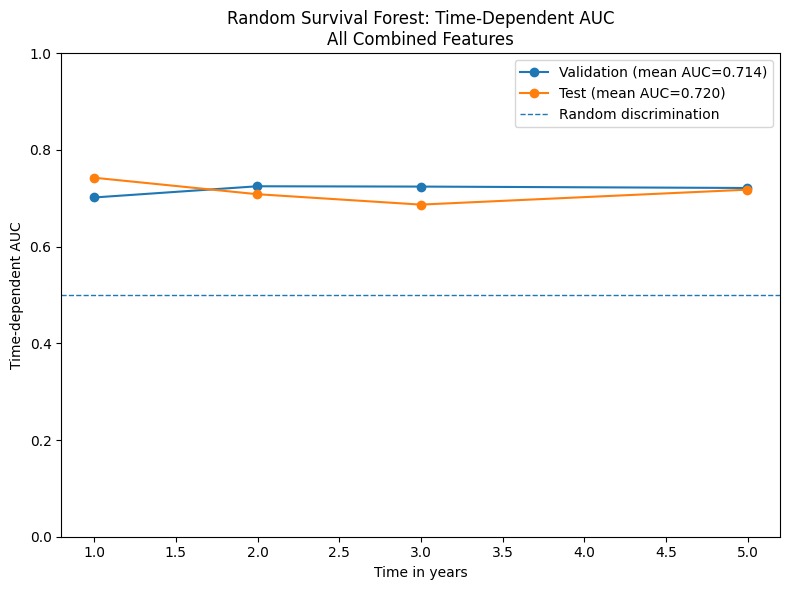

In [ ]:
all_auc_df.to_csv(
    OUTPUT_DIR / "rsf_all_combined_time_dependent_auc.csv",
    index=False,
)
plt.figure(figsize=(8, 6))

plt.plot(
    validation_auc_df["time_years"],
    validation_auc_df["auc"],
    marker="o",
    label=(
        f"Validation "
        f"(mean AUC={validation_mean_auc:.3f})"
    ),
)

plt.plot(
    test_auc_df["time_years"],
    test_auc_df["auc"],
    marker="o",
    label=(
        f"Test "
        f"(mean AUC={test_mean_auc:.3f})"
    ),
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Random discrimination",
)

plt.xlabel("Time in years")
plt.ylabel("Time-dependent AUC")
plt.title(
    "Random Survival Forest: Time-Dependent AUC\n"
    "All Combined Features"
)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "rsf_all_combined_auc.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

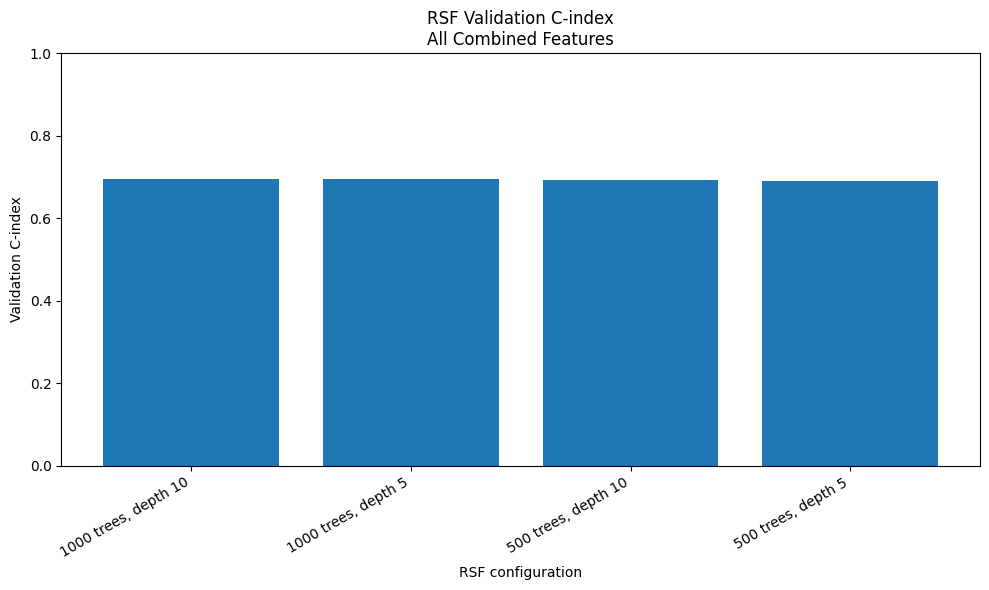

In [ ]:
plot_results_df = configuration_results_df.loc[
    configuration_results_df["completed"]
].copy()

positions = np.arange(len(plot_results_df))

plt.figure(figsize=(10, 6))

plt.bar(
    positions,
    plot_results_df["validation_c_index"],
)

plt.xticks(
    positions,
    plot_results_df["configuration"],
    rotation=30,
    ha="right",
)

plt.xlabel("RSF configuration")
plt.ylabel("Validation C-index")
plt.title(
    "RSF Validation C-index\n"
    "All Combined Features"
)
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "rsf_all_combined_validation_cindex.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

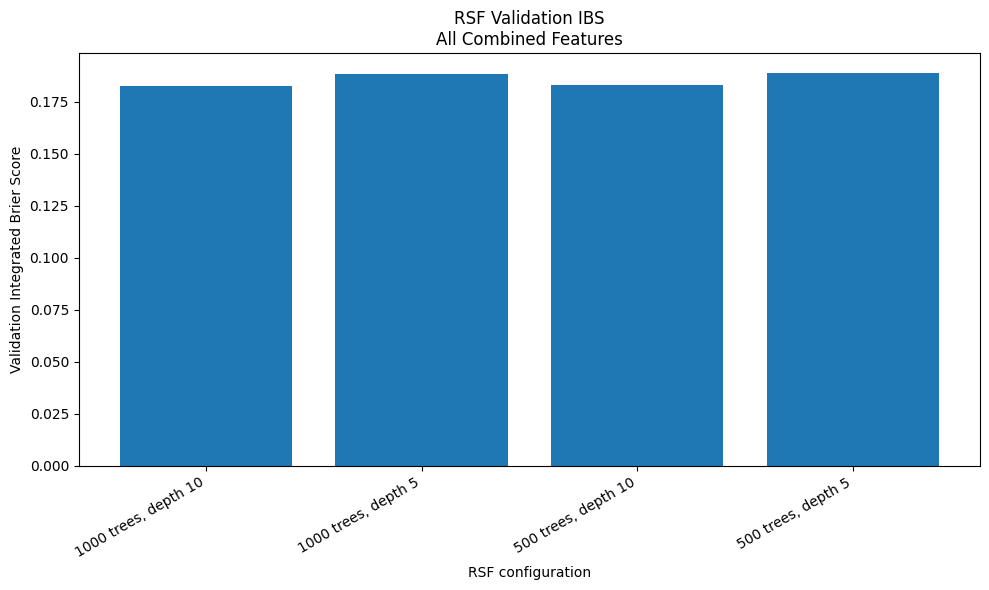

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    positions,
    plot_results_df["validation_ibs"],
)

plt.xticks(
    positions,
    plot_results_df["configuration"],
    rotation=30,
    ha="right",
)

plt.xlabel("RSF configuration")
plt.ylabel("Validation Integrated Brier Score")
plt.title(
    "RSF Validation IBS\n"
    "All Combined Features"
)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "rsf_all_combined_validation_ibs.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Training-derived risk cutoff: 43.445383669103116


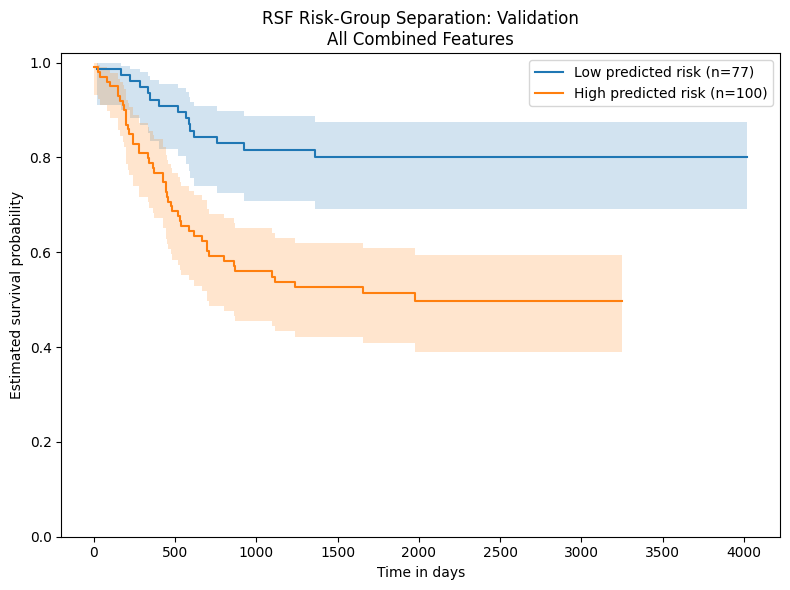

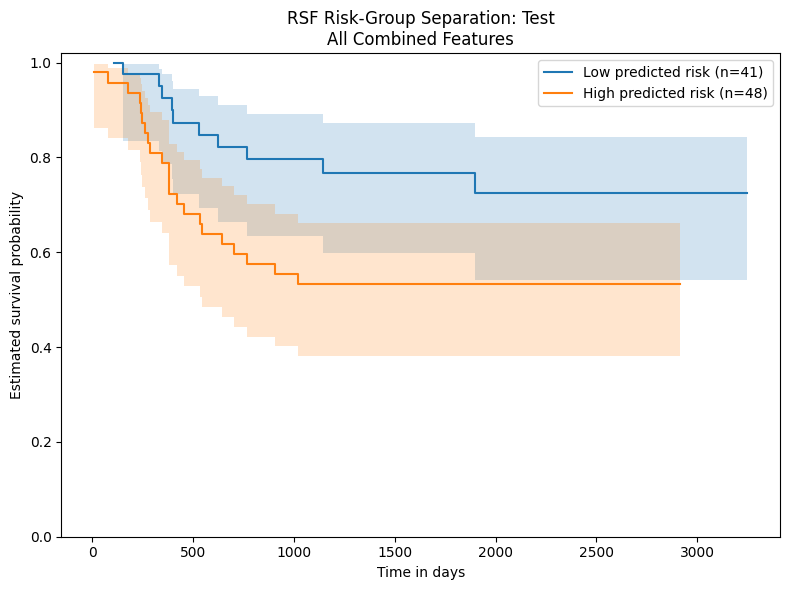

In [ ]:
TRAINING_RISK_CUTOFF = float(
    np.median(train_risk_scores)
)

print("Training-derived risk cutoff:", TRAINING_RISK_CUTOFF)
def plot_km_by_predicted_risk(
    y: np.ndarray,
    risk_scores: np.ndarray,
    cutoff: float,
    dataset_name: str,
) -> pd.DataFrame:
    risk_groups = np.where(
        risk_scores >= cutoff,
        "High predicted risk",
        "Low predicted risk",
    )

    output_df = pd.DataFrame({
        DURATION_COL: y["time"],
        EVENT_COL: y["event"].astype(int),
        "predicted_risk": risk_scores,
        "predicted_risk_group": risk_groups,
    })

    plt.figure(figsize=(8, 6))

    for group_name in [
        "Low predicted risk",
        "High predicted risk",
    ]:
        mask = risk_groups == group_name

        if mask.sum() == 0:
            continue

        km_time, km_survival, km_confidence = (
            kaplan_meier_estimator(
                y["event"][mask],
                y["time"][mask],
                conf_type="log-log",
            )
        )

        plt.step(
            km_time,
            km_survival,
            where="post",
            label=f"{group_name} (n={mask.sum()})",
        )

        plt.fill_between(
            km_time,
            km_confidence[0],
            km_confidence[1],
            step="post",
            alpha=0.2,
        )

    plt.xlabel("Time in days")
    plt.ylabel("Estimated survival probability")
    plt.title(
        f"RSF Risk-Group Separation: {dataset_name}\n"
        "All Combined Features"
    )
    plt.ylim(0, 1.02)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"rsf_all_combined_{dataset_name.lower()}_km.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return output_df
validation_risk_group_df = plot_km_by_predicted_risk(
    y_validation,
    validation_risk_scores,
    TRAINING_RISK_CUTOFF,
    "Validation",
)

test_risk_group_df = plot_km_by_predicted_risk(
    y_test,
    test_risk_scores,
    TRAINING_RISK_CUTOFF,
    "Test",
)

In [ ]:
def rsf_cindex_scorer(
    model: RandomSurvivalForest,
    X: pd.DataFrame,
    y: np.ndarray,
) -> float:
    risk_scores = model.predict(X)

    return float(
        concordance_index_censored(
            y["event"],
            y["time"],
            risk_scores,
        )[0]
    )
permutation_results = permutation_importance(
    best_model,
    X_validation,
    y_validation,
    scoring=rsf_cindex_scorer,
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "importance_mean":
        permutation_results.importances_mean,
    "importance_std":
        permutation_results.importances_std,
})

importance_df = (
    importance_df
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(importance_df.head(30))
importance_df.to_csv(
    OUTPUT_DIR / "rsf_all_combined_permutation_importance.csv",
    index=False,
)

Plot the 20 most important features:

TOP_N = min(20, len(importance_df))

importance_plot_df = (
    importance_df
    .head(TOP_N)
    .sort_values("importance_mean")
)

plt.figure(
    figsize=(
        10,
        max(7, TOP_N * 0.4),
    )
)

plt.barh(
    importance_plot_df["feature"],
    importance_plot_df["importance_mean"],
    xerr=importance_plot_df["importance_std"],
)

plt.axvline(
    0,
    linewidth=1,
)

plt.xlabel(
    "Decrease in validation C-index after permutation"
)
plt.ylabel("Feature")
plt.title(
    f"Top {TOP_N} RSF Permutation Importances\n"
    "All Combined Features"
)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "rsf_all_combined_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

SyntaxError: invalid syntax (2033012834.py, line 47)

In [ ]:
def predict_survival_at_time(
    model: RandomSurvivalForest,
    X: pd.DataFrame,
    time_point: float,
) -> np.ndarray:
    survival_functions = model.predict_survival_function(X)

    return np.array([
        survival_function(time_point)
        for survival_function in survival_functions
    ])
def create_prediction_table(
    original_df: pd.DataFrame,
    X: pd.DataFrame,
    y: np.ndarray,
    risk_scores: np.ndarray,
    dataset_name: str,
) -> pd.DataFrame:
    prediction_df = pd.DataFrame({
        DURATION_COL: y["time"],
        EVENT_COL: y["event"].astype(int),
        "predicted_risk": risk_scores,
        "predicted_survival_1_year":
            predict_survival_at_time(
                best_model,
                X,
                365.0,
            ),
        "predicted_survival_2_years":
            predict_survival_at_time(
                best_model,
                X,
                730.0,
            ),
        "predicted_survival_3_years":
            predict_survival_at_time(
                best_model,
                X,
                1095.0,
            ),
        "predicted_risk_group": np.where(
            risk_scores >= TRAINING_RISK_CUTOFF,
            "High predicted risk",
            "Low predicted risk",
        ),
        "dataset": dataset_name,
        "configuration": BEST_CONFIGURATION,
    })

    if PATIENT_ID_COL in original_df.columns:
        prediction_df.insert(
            0,
            PATIENT_ID_COL,
            original_df[PATIENT_ID_COL].to_numpy(),
        )

    if SAMPLE_ID_COL in original_df.columns:
        insertion_position = (
            1
            if PATIENT_ID_COL in prediction_df.columns
            else 0
        )

        prediction_df.insert(
            insertion_position,
            SAMPLE_ID_COL,
            original_df[SAMPLE_ID_COL].to_numpy(),
        )

    return prediction_df
train_predictions_df = create_prediction_table(
    train_df,
    X_train,
    y_train,
    train_risk_scores,
    "Training",
)

validation_predictions_df = create_prediction_table(
    validation_df,
    X_validation,
    y_validation,
    validation_risk_scores,
    "Validation",
)

test_predictions_df = create_prediction_table(
    test_df,
    X_test,
    y_test,
    test_risk_scores,
    "Test",
)

all_predictions_df = pd.concat(
    [
        train_predictions_df,
        validation_predictions_df,
        test_predictions_df,
    ],
    ignore_index=True,
)

display(all_predictions_df.head())
all_predictions_df.to_csv(
    OUTPUT_DIR / "rsf_all_combined_patient_predictions.csv",
    index=False,
)

,PATIENT_ID,SAMPLE_ID,OS_DAYS,OS_EVENT,predicted_risk,predicted_survival_1_year,predicted_survival_2_years,predicted_survival_3_years,predicted_risk_group,dataset,configuration
0,TARGET-20-PARNIL,TARGET-20-PARNIL-09,1.0,1,42.620679,0.847549,0.742125,0.735197,Low predicted risk,Training,"1000 trees, depth 10"
1,TARGET-20-PAPZYS,TARGET-20-PAPZYS-09,2566.0,0,47.242783,0.858699,0.711205,0.630122,High predicted risk,Training,"1000 trees, depth 10"
2,TARGET-20-PASKUA,TARGET-20-PASKUA-09,721.0,1,86.859841,0.746187,0.499985,0.442832,High predicted risk,Training,"1000 trees, depth 10"
3,TARGET-20-PARMME,TARGET-20-PARMME-09,2363.0,0,28.753940,0.907104,0.812095,0.773121,Low predicted risk,Training,"1000 trees, depth 10"
4,TARGET-20-PARTYV,TARGET-20-PARTYV-09,406.0,0,43.073829,0.858971,0.716929,0.679212,Low predicted risk,Training,"1000 trees, depth 10"


In [ ]:
MODEL_PATH = OUTPUT_DIR / "rsf_all_combined_model.pkl"

with open(MODEL_PATH, "wb") as file:
    pickle.dump(best_model, file)

print("Model saved to:", MODEL_PATH)

Model saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/rsf_results/all_combined_features/rsf_all_combined_model.pkl


In [ ]:
configuration = {
    "model": "Random Survival Forest",
    "feature_set": "All Combined Features",
    "requested_features": REQUESTED_FEATURES,
    "used_features": MODEL_FEATURES,
    "excluded_columns": EXCLUDED_COLUMNS,
    "zero_variance_features_removed":
        zero_variance_features,
    "selected_configuration":
        BEST_CONFIGURATION,
    "n_estimators":
        int(best_result["n_estimators"]),
    "max_depth":
        int(best_result["max_depth"]),
    "min_samples_split":
        FIXED_RSF_PARAMETERS["min_samples_split"],
    "min_samples_leaf":
        FIXED_RSF_PARAMETERS["min_samples_leaf"],
    "max_features":
        FIXED_RSF_PARAMETERS["max_features"],
    "bootstrap":
        FIXED_RSF_PARAMETERS["bootstrap"],
    "random_state":
        FIXED_RSF_PARAMETERS["random_state"],
    "duration_column":
        DURATION_COL,
    "event_column":
        EVENT_COL,
    "auc_times_days":
        REQUESTED_AUC_TIMES.tolist(),
    "training_risk_cutoff":
        TRAINING_RISK_CUTOFF,
    "selection_rule": (
        "Highest validation C-index, followed by "
        "lowest validation IBS, highest validation mean AUC, "
        "and smallest train-validation C-index gap."
    ),
}
CONFIGURATION_PATH = (
    OUTPUT_DIR / "rsf_all_combined_configuration.json"
)

with open(CONFIGURATION_PATH, "w") as file:
    json.dump(
        configuration,
        file,
        indent=4,
    )

print("Configuration saved to:", CONFIGURATION_PATH)

Configuration saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/rsf_results/all_combined_features/rsf_all_combined_configuration.json


In [ ]:
print("\n" + "=" * 75)
print("FINAL RSF RESULTS — ALL COMBINED FEATURES")
print("=" * 75)

print("Selected configuration:", BEST_CONFIGURATION)
print("Predictors used:", len(MODEL_FEATURES))
print(f"OOB C-index: {best_model.oob_score_:.4f}")

print("\nValidation")
print(f"C-index: {validation_c_index:.4f}")
print(f"IBS: {validation_ibs:.4f}")
print(f"Mean AUC: {validation_mean_auc:.4f}")

print("\nTest")
print(f"C-index: {test_c_index:.4f}")
print(f"IBS: {test_ibs:.4f}")
print(f"Mean AUC: {test_mean_auc:.4f}")

print("\nOutputs:")
print(OUTPUT_DIR)

print("=" * 75)


FINAL RSF RESULTS — ALL COMBINED FEATURES
Selected configuration: 1000 trees, depth 10
Predictors used: 64
OOB C-index: 0.6522

Validation
C-index: 0.6944
IBS: 0.1824
Mean AUC: 0.7145

Test
C-index: 0.6745
IBS: 0.1831
Mean AUC: 0.7199

Outputs:
/content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/rsf_results/all_combined_features
